In [1]:
import copy, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from General_LR_reg import compute_model, compute_cost_reg, compute_gradient_reg, gradient_descent_reg
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

In [2]:
np.random.seed(1)
X_tmp = np.random.rand(5,6)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1,)-0.5
b_tmp = 0.5
lambda_tmp = 0.7
cost_tmp = compute_cost_reg(x=X_tmp, y=y_tmp, w=w_tmp, b=b_tmp, model=compute_model, lambda_=lambda_tmp)

print("Regularized cost:", cost_tmp)

Regularized cost: 0.07917239320214275


In [3]:
np.random.seed(1)
X_tmp = np.random.rand(5,3)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1])
b_tmp = 0.5
lambda_tmp = 0.7
dj_db_tmp, dj_dw_tmp = compute_gradient_reg(x=X_tmp, y=y_tmp, w=w_tmp, b=b_tmp, lambda_=lambda_tmp, model=compute_model)

print(f"dj_db: {dj_db_tmp}", )
print(f"Regularized dj_dw:\n {dj_dw_tmp.tolist()}", )

dj_db: [0.3  0.49 0.22]
Regularized dj_dw:
 0.6648774569425726


In [4]:
X_train = np.array([[2104, 5, 1, 45],
                    [1416, 3, 2, 40],
                    [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [5]:
df1 = pd.DataFrame({"Size": X_train[:, 0],
                    "Number of bedrooms": X_train[:, 1],
                    "Number of floors": X_train[:, 2],
                    "Age of house": X_train[:, 3],
                   "Prices": y_train})
df1

,Size,Number of bedrooms,Number of floors,Age of house,Prices
0,2104,5,1,45,460
1,1416,3,2,40,232
2,852,2,1,35,178


In [6]:
b_init = 785.1811367994083
w_init = np.array([0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


In [7]:
w_final, b_final, J_hist, p_hist = gradient_descent_reg(X_train,
                     y_train,
                     w = np.zeros_like(w_init),
                     b = 0,
                     alpha = 1.0e-9,
                     num_iters = 10000)

print(f"b, w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost 49285.16
Iteration 1000: Cost 1104.75
Iteration 2000: Cost 700.46
Iteration 3000: Cost 697.05
Iteration 4000: Cost 697.00
Iteration 5000: Cost 696.98
Iteration 6000: Cost 696.96
Iteration 7000: Cost 696.94
Iteration 8000: Cost 696.91
Iteration 9000: Cost 696.89
Iteration 10000: Cost 696.87
b, w found by gradient descent: 0.00,[ 2.02e-01  5.31e-04 -6.64e-05  3.67e-03] 
prediction: 425.60, target value: 460
prediction: 286.47, target value: 232
prediction: 172.41, target value: 178


In [8]:
w_final, b_final, J_hist, p_hist = gradient_descent_reg(X_train,
                     y_train,
                     w = np.zeros_like(w_init),
                     b = 0,
                     alpha = 1.0e-9,
                     num_iters = 5000)

print(f"b, w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost 49285.16
Iteration  500: Cost 5147.75
Iteration 1000: Cost 1104.75
Iteration 1500: Cost 734.40
Iteration 2000: Cost 700.46
Iteration 2500: Cost 697.35
Iteration 3000: Cost 697.05
Iteration 3500: Cost 697.01
Iteration 4000: Cost 697.00
Iteration 4500: Cost 696.99
Iteration 5000: Cost 696.98
b, w found by gradient descent: 0.00,[2.02e-01 4.98e-04 4.85e-05 4.39e-03] 
prediction: 425.59, target value: 460
prediction: 286.47, target value: 232
prediction: 172.42, target value: 178


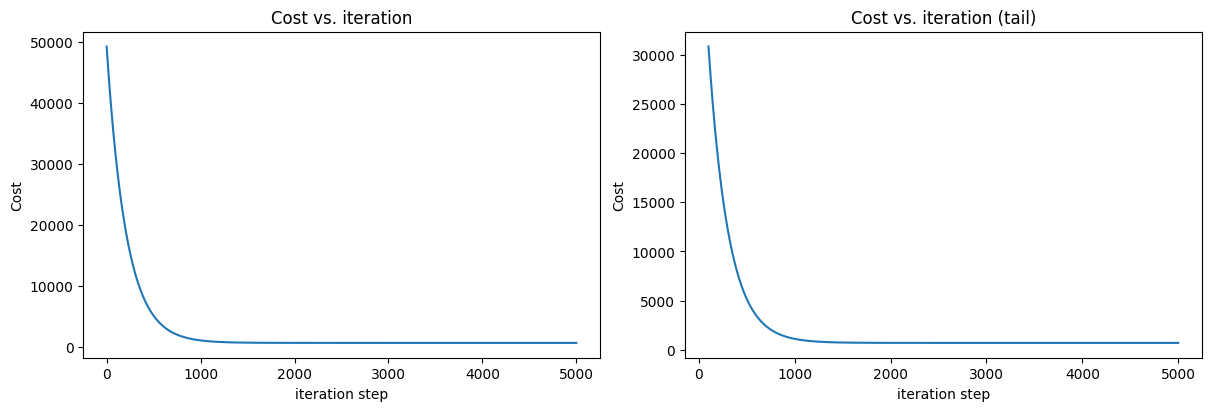

In [9]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()